In [160]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [161]:
df = pd.read_csv('/content/HousePricePrediction.xlsx - Sheet1.csv')
df.head()


,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [162]:
df.shape

(2919, 13)

In [163]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB


In [164]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Id,2919.0,1459.000000,842.787043,0.0,729.5,1459.0,2188.5,2918.0
MSSubClass,2919.0,57.137718,42.517628,20.0,20.0,50.0,70.0,190.0
LotArea,2919.0,10168.114080,7886.996359,1300.0,7478.0,9453.0,11570.0,215245.0
OverallCond,2919.0,5.564577,1.113131,1.0,5.0,5.0,6.0,9.0
YearBuilt,2919.0,1971.312778,30.291442,1872.0,1953.5,1973.0,2001.0,2010.0
YearRemodAdd,2919.0,1984.264474,20.894344,1950.0,1965.0,1993.0,2004.0,2010.0
BsmtFinSF2,2918.0,49.582248,169.205611,0.0,0.0,0.0,0.0,1526.0
TotalBsmtSF,2918.0,1051.777587,440.766258,0.0,793.0,989.5,1302.0,6110.0
SalePrice,1460.0,180921.195890,79442.502883,34900.0,129975.0,163000.0,214000.0,755000.0


In [165]:
df.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,4
LotArea,0
LotConfig,0
BldgType,0
OverallCond,0
YearBuilt,0
YearRemodAdd,0
Exterior1st,1


In [166]:
df.dropna(inplace = True)

**EDA**

In [167]:
# Label Encoding

In [168]:
from sklearn.preprocessing import LabelEncoder

for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])

In [169]:
df.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,3,8450,4,0,5,2003,2003,12,0.0,856.0,208500.0
1,1,20,3,9600,2,0,8,1976,1976,8,0.0,1262.0,181500.0
2,2,60,3,11250,4,0,5,2001,2002,12,0.0,920.0,223500.0
3,3,70,3,9550,0,0,5,1915,1970,13,0.0,756.0,140000.0
4,4,60,3,14260,2,0,5,2000,2000,12,0.0,1145.0,250000.0


In [170]:
# Correlation

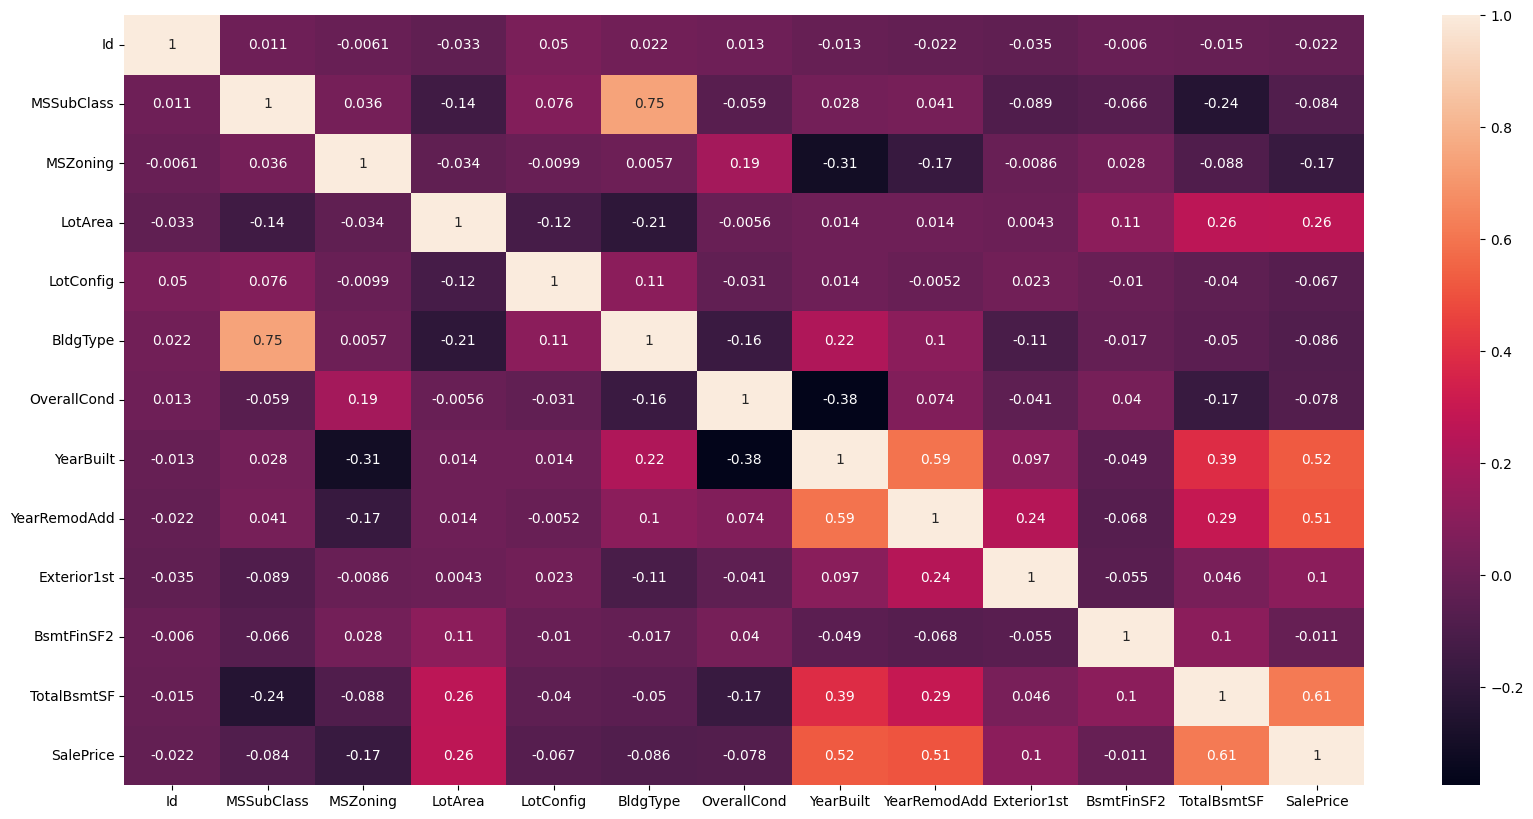

In [171]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(),annot=True)
plt.show()

In [172]:
# Barplot for correlation with Sale Price

<Axes: xlabel='None', ylabel='SalePrice'>

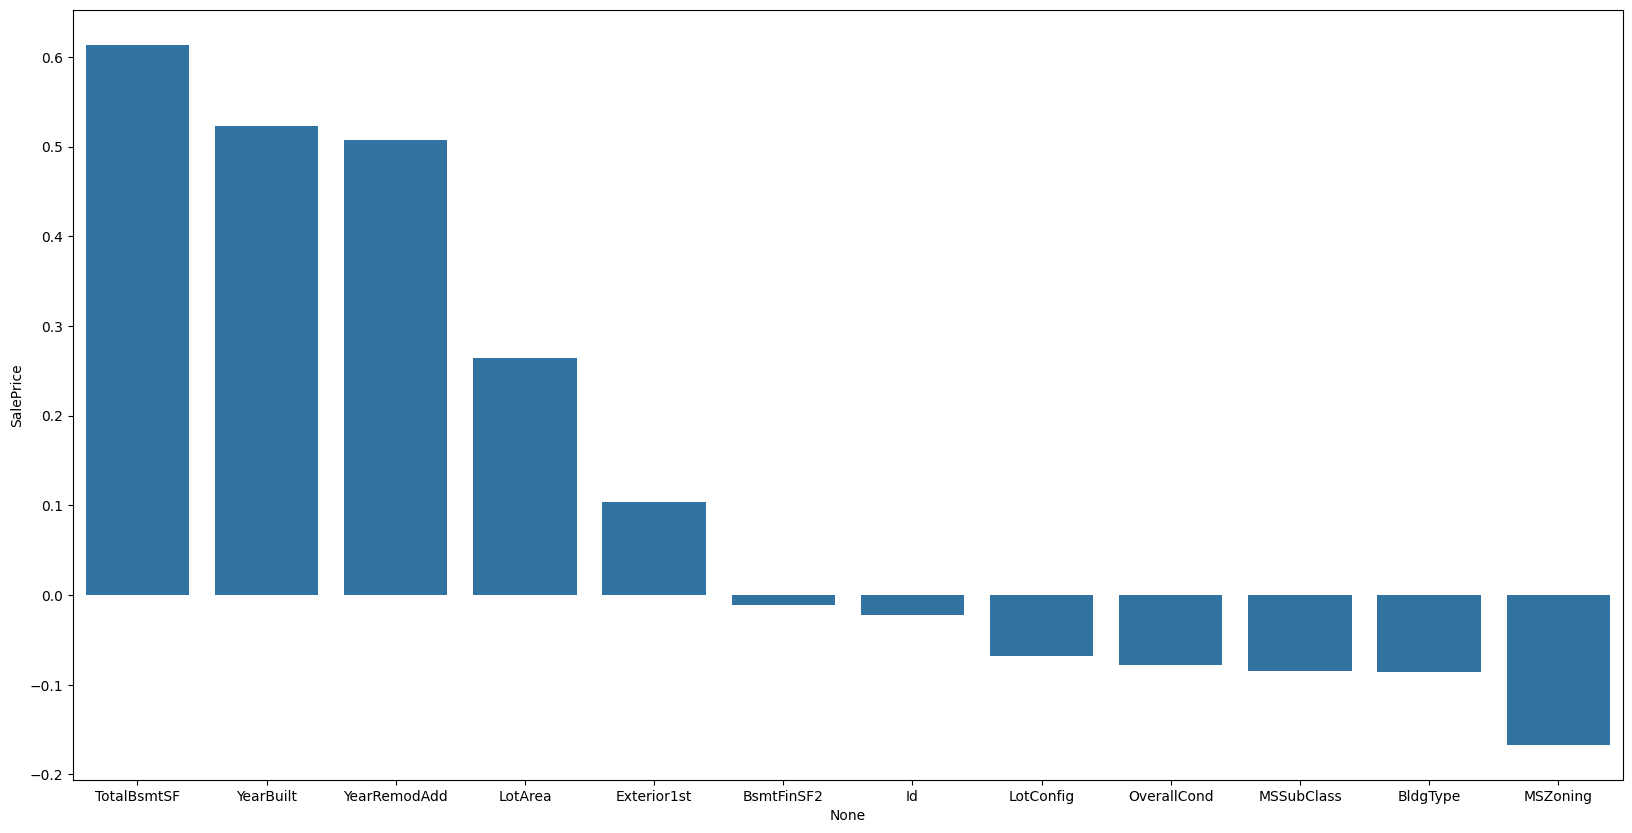

In [173]:
plt.figure(figsize=(20,10))
sns.barplot(x=df.corr()['SalePrice'][:-1].sort_values(ascending=False).index,y=df.corr()['SalePrice'][:-1].sort_values(ascending=False))

In [174]:
# Checking for Outliers

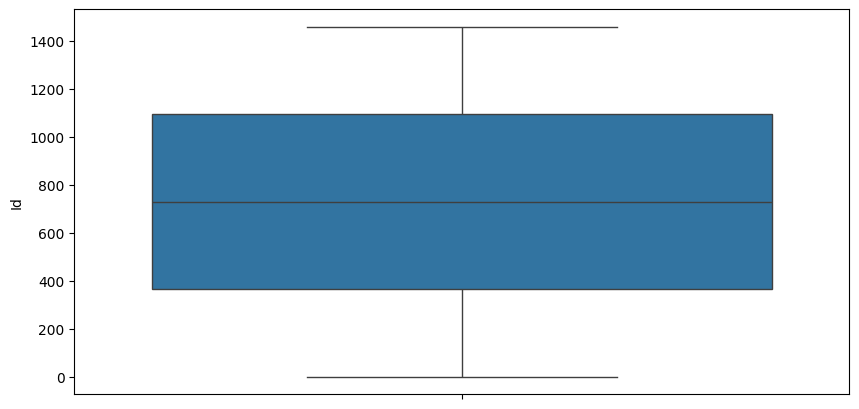

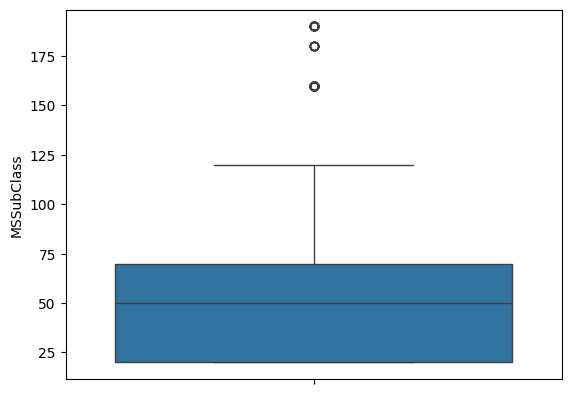

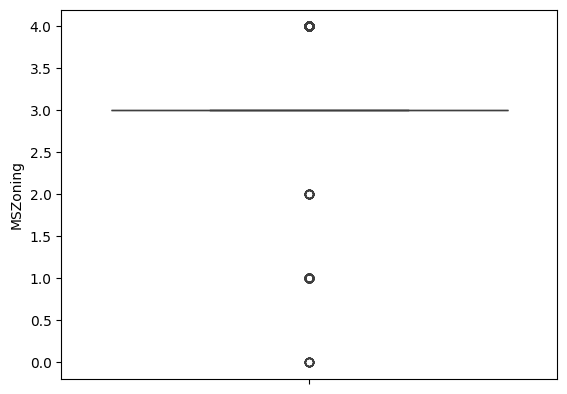

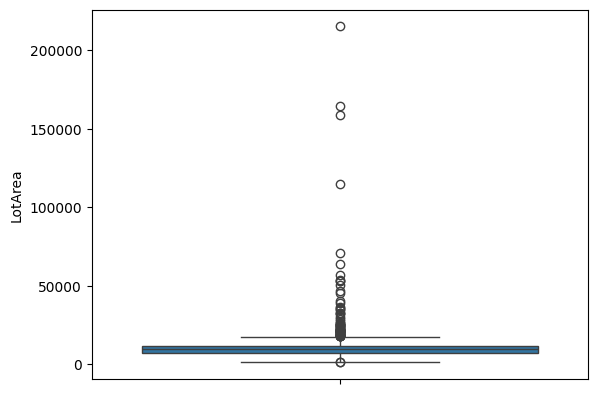

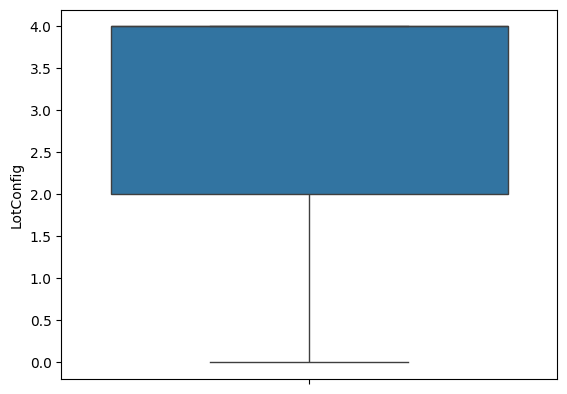

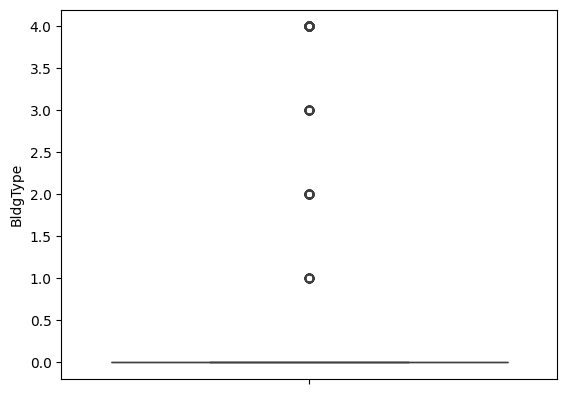

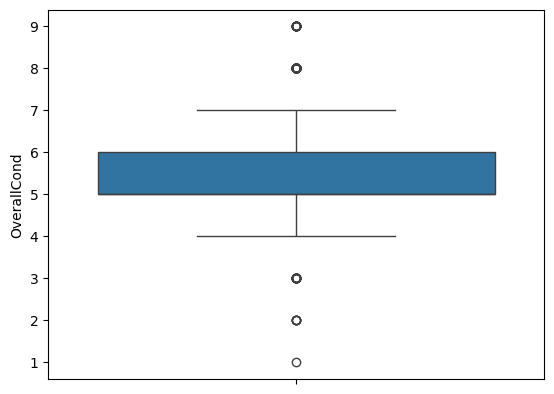

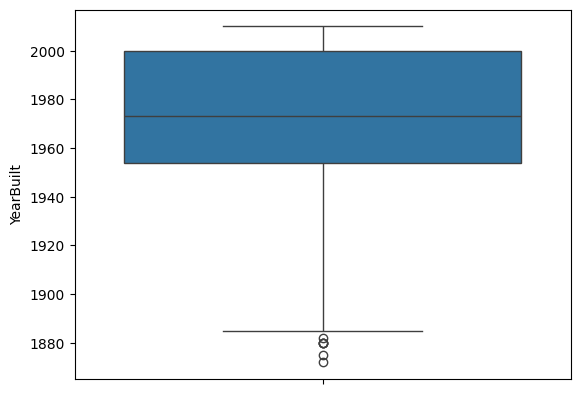

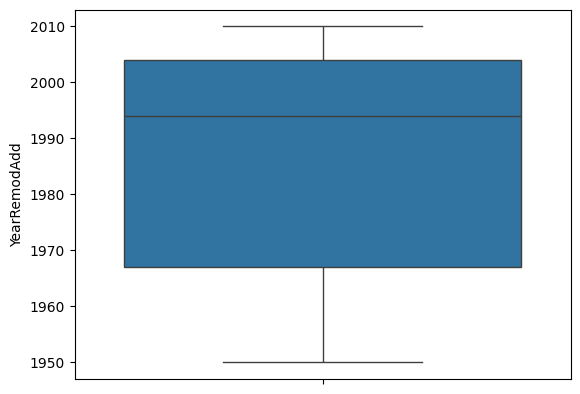

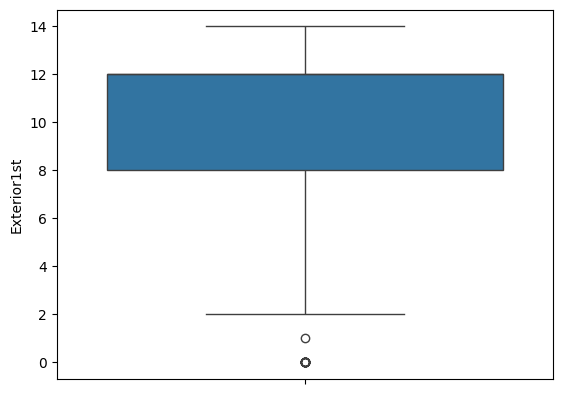

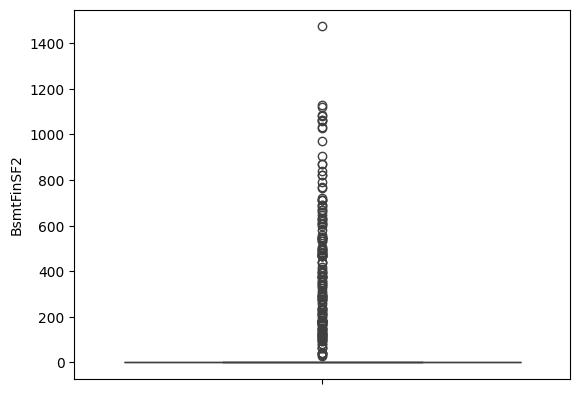

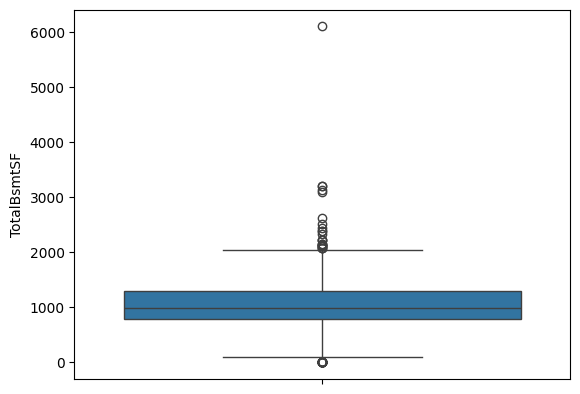

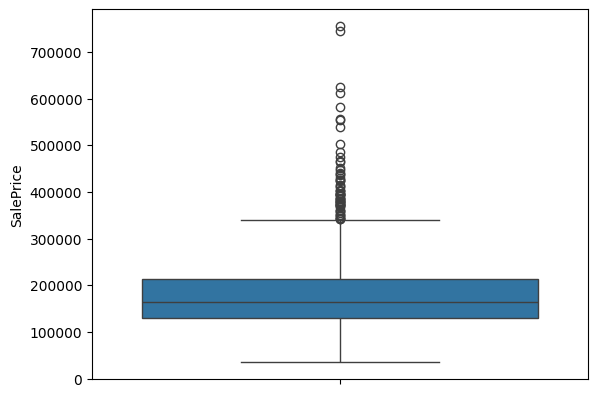

In [175]:
plt.figure(figsize=(10,5))
for col in df.columns:
    sns.boxplot(df[col])
    plt.show()

In [176]:
#Removing outliers

In [177]:
for col in df.columns:
    if df[col].dtype == 'int64' or df[col].dtype == 'float64':
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3-q1
        upper_limit = q3 + 1.5*iqr
        lower_limit = q1 - 1.5*iqr
        df[col] = np.where(df[col]>upper_limit,upper_limit,np.where(df[col]<lower_limit,lower_limit,df[col]))

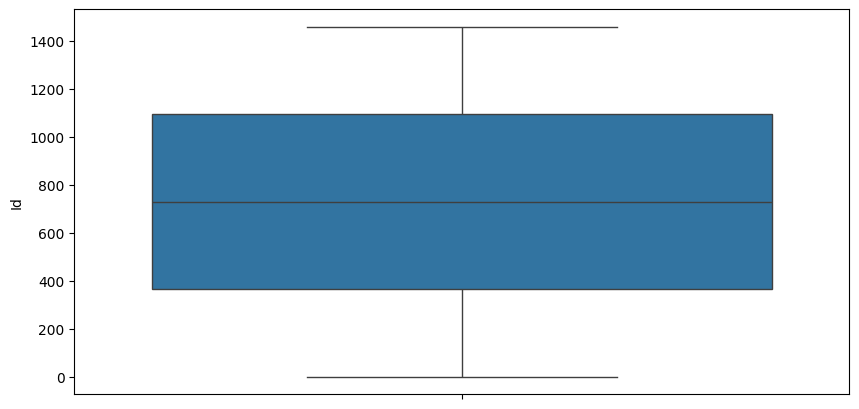

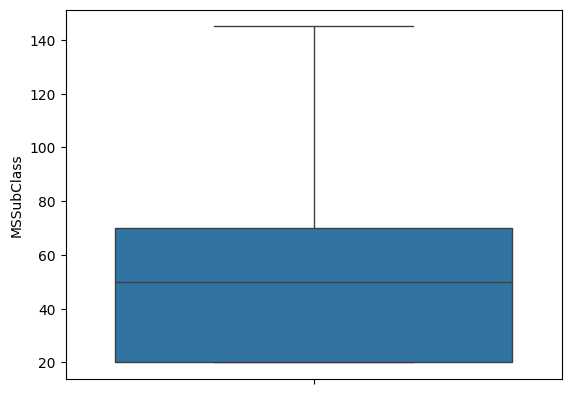

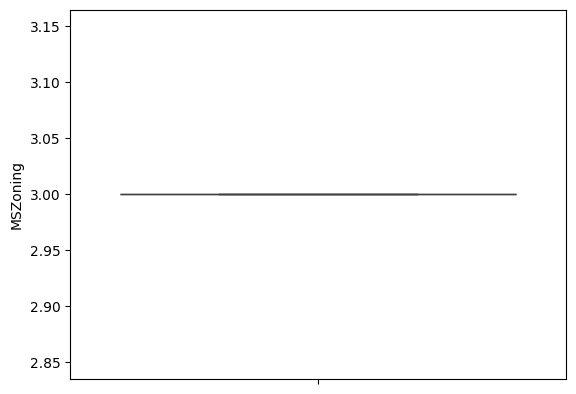

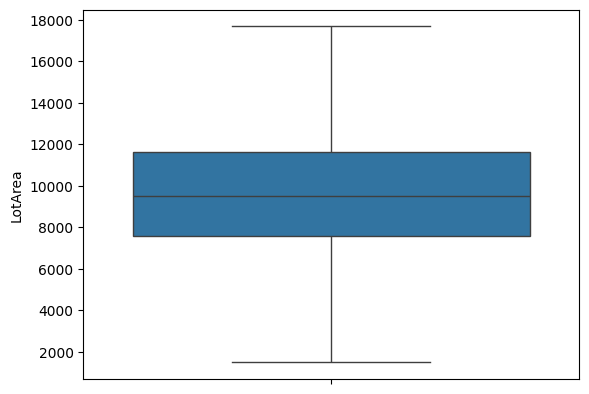

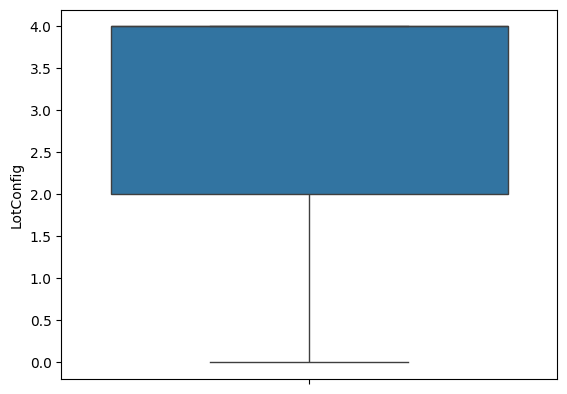

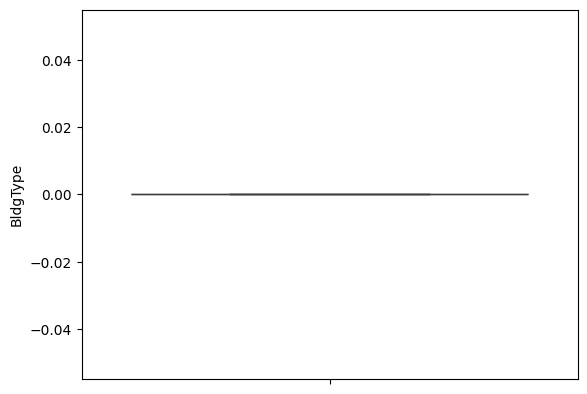

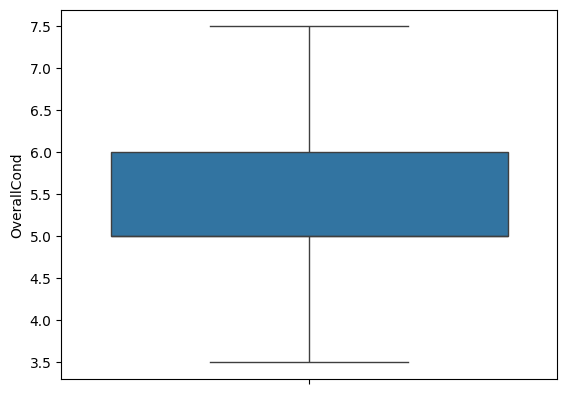

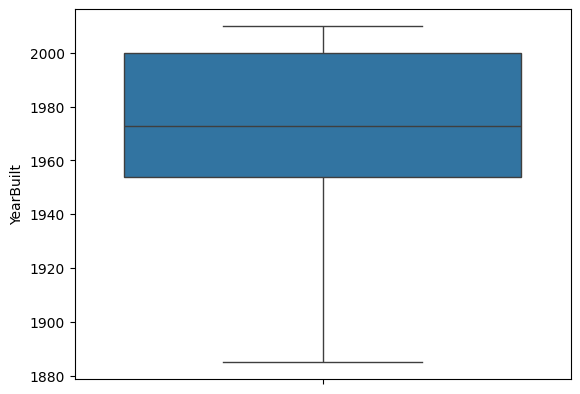

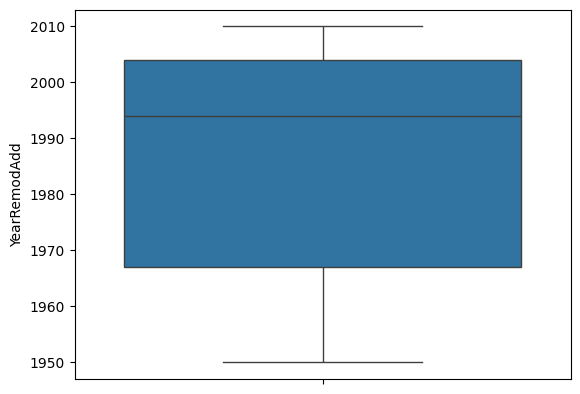

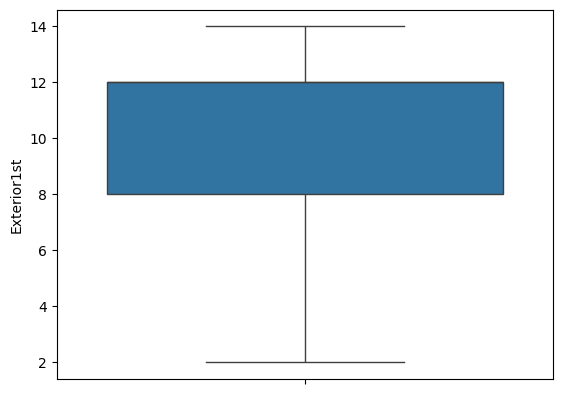

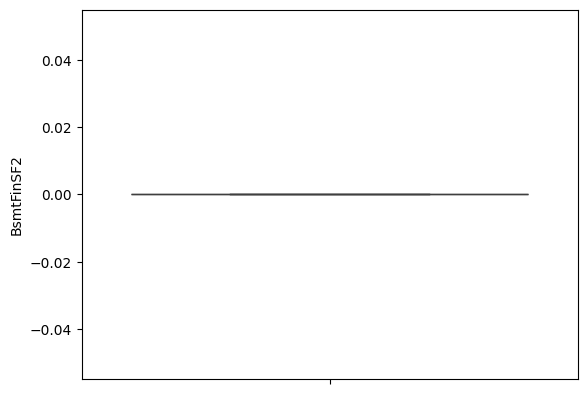

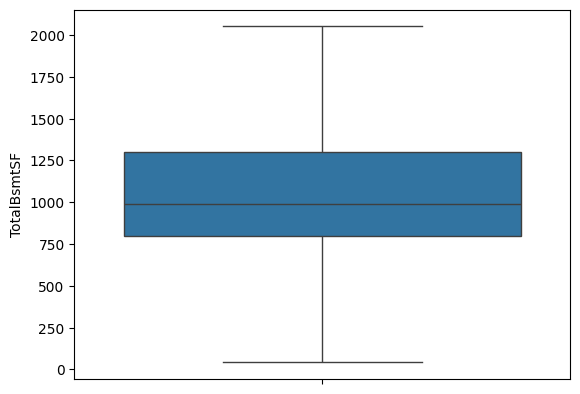

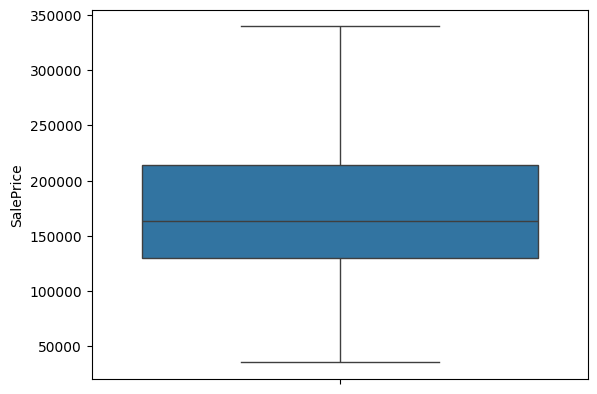

In [178]:
plt.figure(figsize=(10,5))
for col in df.columns:
    sns.boxplot(df[col])
    plt.show()


**Model Building**

1. Descision Tree
2. Random Forest
3. Gradient boost
4. ADAboost
5. XGBoost


**Spliting the data**

In [179]:
from sklearn.model_selection import train_test_split

x = df.drop('SalePrice',axis=1)
y = df['SalePrice']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [206]:
# Scaling

In [207]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [208]:
# Descision Tree

In [209]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

dt = DecisionTreeRegressor()
dt.fit(x_train,y_train)
y_pred = dt.predict(x_test)

In [210]:
# Evaluation

In [211]:
mae_value = mean_absolute_error(y_test, y_pred)
mse_value = mean_squared_error(y_test, y_pred)
r2_score_value_dt = r2_score(y_test, y_pred)

print('Mean Absolute Error:', mae_value)
print('Mean Squared Error:', mse_value)
print('R2 Score:', r2_score_value_dt)

Mean Absolute Error: 26655.130136986303
Mean Squared Error: 1410662876.359589
R2 Score: 0.7114766302969684


In [212]:
# Random Forest

In [213]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(x_train,y_train)
y_pred = rf.predict(x_test)

In [214]:
# Evaluation

In [215]:
mae_value = mean_absolute_error(y_test, y_pred)
mse_value = mean_squared_error(y_test, y_pred)
r2_score_value_rf = r2_score(y_test, y_pred)

print('Mean Absolute Error:', mae_value)
print('Mean Squared Error:', mse_value)
print('R2 Score:', r2_score_value_rf)

Mean Absolute Error: 20848.02589041096
Mean Squared Error: 828171840.745691
R2 Score: 0.8306137248030905


In [216]:
# Adaboost

In [217]:
from sklearn.ensemble import AdaBoostRegressor

ada = AdaBoostRegressor()
ada.fit(x_train,y_train)
y_pred = ada.predict(x_test)

In [218]:
# Evalauation

In [219]:
mae_value = mean_absolute_error(y_test, y_pred)
mse_value = mean_squared_error(y_test, y_pred)
r2_score_value_ada = r2_score(y_test, y_pred)

print('Mean Absolute Error:', mae_value)
print('Mean Squared Error:', mse_value)
print('R2 Score:', r2_score_value_ada)

Mean Absolute Error: 28979.403874765303
Mean Squared Error: 1416470935.8671532
R2 Score: 0.7102887058618385


In [220]:
# Gradient Boost

In [221]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor()
gb.fit(x_train,y_train)
y_pred = gb.predict(x_test)

In [222]:
# Evaluation

In [223]:
mae_value = mean_absolute_error(y_test, y_pred)
mse_value = mean_squared_error(y_test, y_pred)
r2_score_value_gb = r2_score(y_test, y_pred)

print('Mean Absolute Error:', mae_value)
print('Mean Squared Error:', mse_value)
print('R2 Score:', r2_score_value_gb)

Mean Absolute Error: 21090.303815950265
Mean Squared Error: 830943112.6599758
R2 Score: 0.8300469155927026


In [224]:
# XGboost

In [225]:
from xgboost import XGBRegressor

xgb = XGBRegressor()
xgb.fit(x_train,y_train)
y_pred = xgb.predict(x_test)

In [226]:
# Evaluation

In [227]:
mae_value = mean_absolute_error(y_test, y_pred)
mse_value = mean_squared_error(y_test, y_pred)
r2_score_value_xgb = r2_score(y_test, y_pred)

print('Mean Absolute Error:', mae_value)
print('Mean Squared Error:', mse_value)
print('R2 Score:', r2_score_value_xgb)

Mean Absolute Error: 21134.473004066782
Mean Squared Error: 846614147.123239
R2 Score: 0.8268417134527404


In [228]:
# Linear regression

In [229]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)

In [230]:
# Evaluation

In [231]:
mae_value = mean_absolute_error(y_test, y_pred)
mse_value = mean_squared_error(y_test, y_pred)
r2_score_value_lr = r2_score(y_test, y_pred)

print('Mean Absolute Error:', mae_value)
print('Mean Squared Error:', mse_value)
print('R2 Score:', r2_score_value_lr)

Mean Absolute Error: 29998.53214124426
Mean Squared Error: 1467474183.385608
R2 Score: 0.6998569938727925


Plot for all model

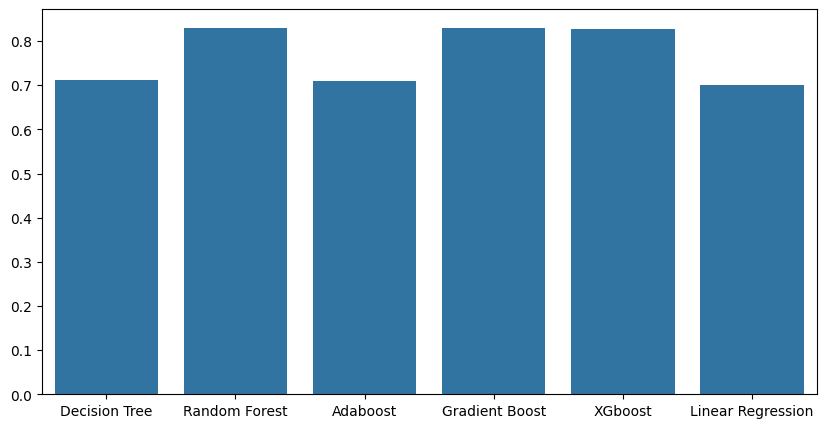

In [232]:
plt.figure(figsize=(10,5))
models = ['Decision Tree','Random Forest','Adaboost','Gradient Boost','XGboost','Linear Regression']

sns.barplot(x=models,y=[r2_score_value_dt,r2_score_value_rf,r2_score_value_ada,r2_score_value_gb,r2_score_value_xgb,r2_score_value_lr])
plt.show()

